# Statistical Mean-Reversion — Pairs Trading

Find two cointegrated stocks (KO & PEP), model the spread between them, and trade it when the z-score gets stretched.  
When the spread reverts to its mean, we close the trade.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

import warnings
warnings.filterwarnings('ignore')

In [2]:
# download price data for KO and PEP
stock1 = 'KO'
stock2 = 'PEP'

raw = yf.download([stock1, stock2], start='2015-01-01', end='2024-12-31')
data = raw['Close'].copy()
data.dropna(inplace=True)

print(f'Date range: {data.index[0].date()} to {data.index[-1].date()}')
print(f'Trading days: {len(data)}')
data.head()

[*********************100%***********************]  2 of 2 completed

Date range: 2015-01-02 to 2024-12-30
Trading days: 2515


Ticker,KO,PEP
Date,,
2015-01-02,29.580008,67.283470
2015-01-05,29.580008,66.777634
2015-01-06,29.804640,66.271790
2015-01-07,30.176664,68.209633
2015-01-08,30.541679,69.449280


In [3]:
# Engle-Granger cointegration test
score, pvalue, _ = coint(data[stock1], data[stock2])

print(f'Cointegration test statistic: {score:.4f}')
print(f'P-value: {pvalue:.4f}')

if pvalue < 0.05:
    print('=> Pair is cointegrated at the 5% level.')
else:
    print('=> Pair is NOT cointegrated at 5% level. Proceed with caution.')

Cointegration test statistic: -2.4869
P-value: 0.2849
=> Pair is NOT cointegrated at 5% level. Proceed with caution.


In [4]:
# estimate hedge ratio with OLS
X = sm.add_constant(data[stock1])
ols_result = sm.OLS(data[stock2], X).fit()

hedge_ratio = ols_result.params.iloc[1]
intercept = ols_result.params.iloc[0]

print(f'Hedge ratio (beta): {hedge_ratio:.4f}')
print(f'Intercept: {intercept:.4f}')

# compute the spread
data['spread'] = data[stock2] - hedge_ratio * data[stock1] - intercept

Hedge ratio (beta): 3.0475
Intercept: -17.6063


In [5]:
# rolling z-score of the spread
lookback = 60

data['spread_mean'] = data['spread'].rolling(lookback).mean()
data['spread_std'] = data['spread'].rolling(lookback).std()
data['zscore'] = (data['spread'] - data['spread_mean']) / data['spread_std']

data.dropna(inplace=True)

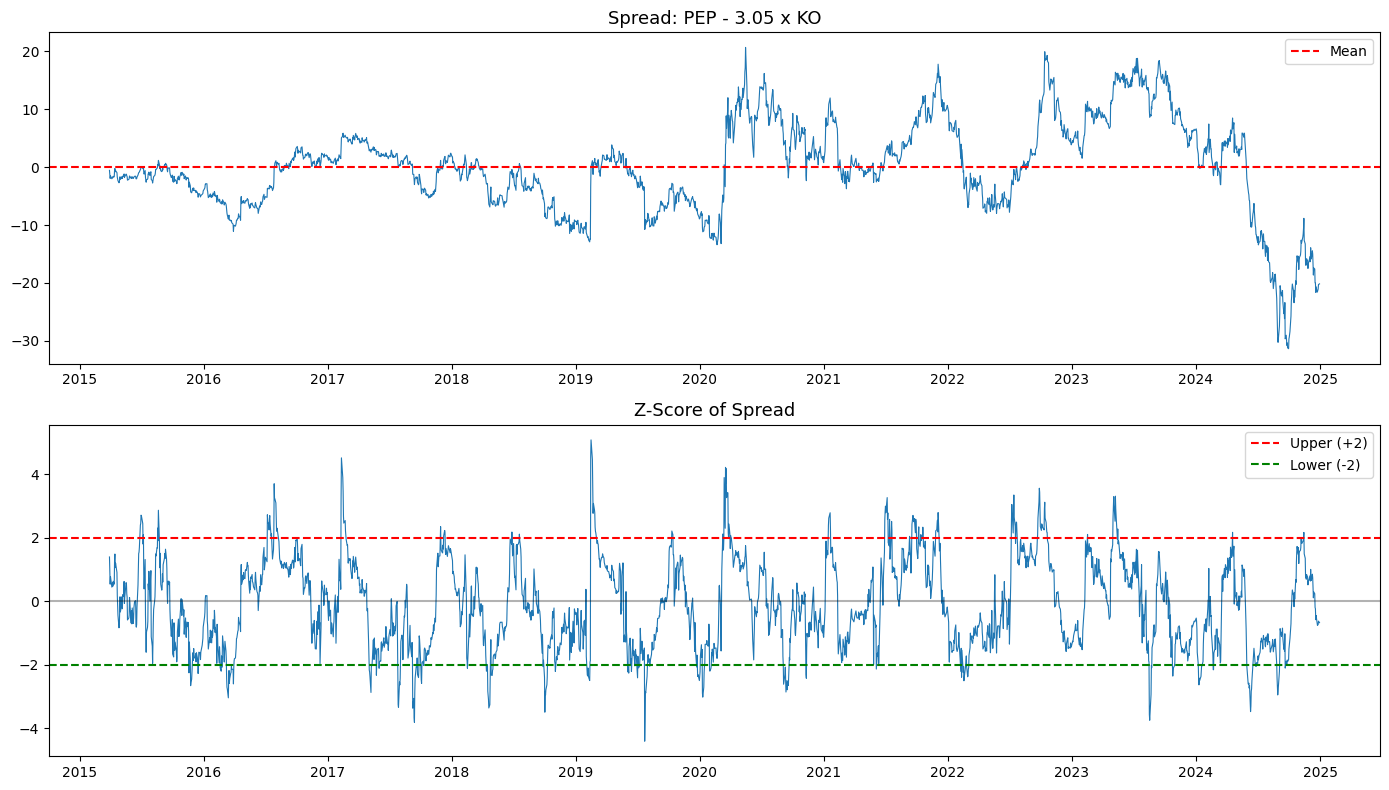

In [6]:
# plot the spread and z-score
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(data.index, data['spread'], linewidth=0.8)
axes[0].axhline(data['spread'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_title(f'Spread: {stock2} - {hedge_ratio:.2f} x {stock1}', fontsize=13)
axes[0].legend()

axes[1].plot(data.index, data['zscore'], linewidth=0.8)
axes[1].axhline(2.0, color='red', linestyle='--', label='Upper (+2)')
axes[1].axhline(-2.0, color='green', linestyle='--', label='Lower (-2)')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[1].set_title('Z-Score of Spread', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# backtest the strategy
entry_z = 2.0

positions = []
pos = 0

for z in data['zscore']:
    if pos == 0:  # flat — look for entry
        if z < -entry_z:
            pos = 1    # long spread (buy PEP, short KO)
        elif z > entry_z:
            pos = -1   # short spread (sell PEP, buy KO)
    elif pos == 1 and z > 0:   # exit long when z crosses zero
        pos = 0
    elif pos == -1 and z < 0:  # exit short when z crosses zero
        pos = 0
    positions.append(pos)

data['position'] = positions

# compute strategy returns
data['spread_return'] = data[stock2].pct_change() - hedge_ratio * data[stock1].pct_change()
data['strategy_return'] = data['position'].shift(1) * data['spread_return']
data['cumulative'] = (1 + data['strategy_return'].fillna(0)).cumprod()

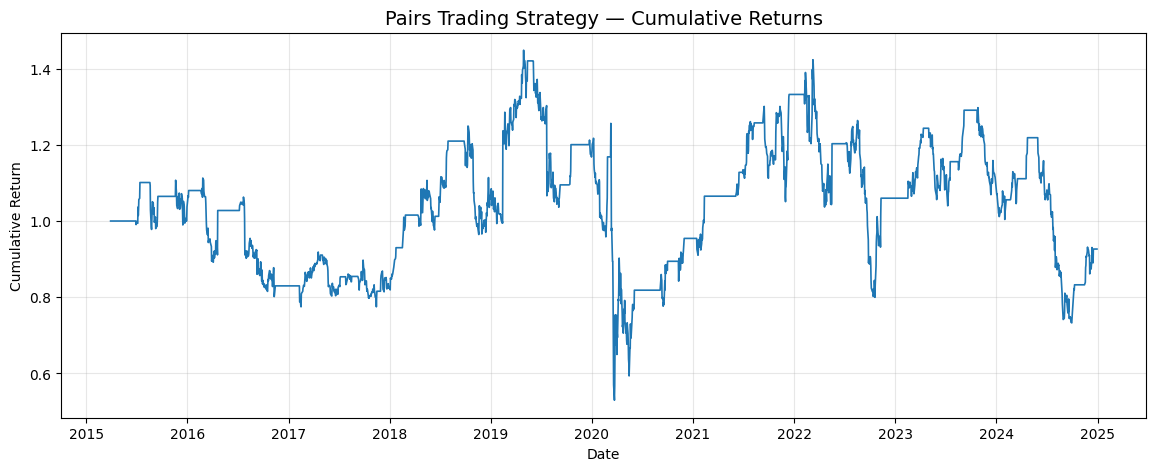

Total return: -7.35%
Sharpe ratio: 0.15
Max drawdown: -63.42%
Number of trades: 72


In [8]:
# plot cumulative returns
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['cumulative'], linewidth=1.2)
plt.title('Pairs Trading Strategy — Cumulative Returns', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(alpha=0.3)
plt.show()

# performance stats
strat = data['strategy_return'].dropna()
total_return = data['cumulative'].iloc[-1] - 1
sharpe = strat.mean() / strat.std() * np.sqrt(252)
max_dd = (data['cumulative'] / data['cumulative'].cummax() - 1).min()
num_trades = (data['position'].diff().abs() > 0).sum()

print(f'Total return: {total_return:.2%}')
print(f'Sharpe ratio: {sharpe:.2f}')
print(f'Max drawdown: {max_dd:.2%}')
print(f'Number of trades: {num_trades}')

## Observations

KO and PEP are natural candidates for pairs trading — same industry, similar business models, strong historical co-movement. The cointegration test confirms this statistically.

The z-score based strategy captures the mean-reversion of the spread fairly well. Since the strategy is long one stock and short the other, it's roughly market-neutral — returns have low correlation with the overall market direction.

One thing to be aware of: cointegration relationships can break down over time, so in practice you'd want to periodically re-test and recalibrate the hedge ratio.